In [1]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path("D:/loan-default-prediction/data/processed/modeling_datset.csv")

model_df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", model_df.shape)
display(model_df.head())

Dataset Shape: (1348099, 13)


,loan_amnt,term_months,int_rate,grade,sub_grade,emp_length_years,home_ownership,annual_inc,verification_status,issue_year,purpose,dti,default_flag
0,3600.0,36,13.99,C,C4,10.0,MORTGAGE,55000.0,Not Verified,2015,debt_consolidation,5.91,0
1,24700.0,36,11.99,C,C1,10.0,MORTGAGE,65000.0,Not Verified,2015,small_business,16.06,0
2,20000.0,60,10.78,B,B4,10.0,MORTGAGE,63000.0,Not Verified,2015,home_improvement,10.78,0
3,10400.0,60,22.45,F,F1,3.0,MORTGAGE,104433.0,Source Verified,2015,major_purchase,25.37,0
4,11950.0,36,13.44,C,C3,4.0,RENT,34000.0,Source Verified,2015,debt_consolidation,10.20,0


In [2]:
train_df = model_df[model_df["issue_year"] <= 2015].copy()

validation_df = model_df[
    model_df["issue_year"].between(2016,2017)
].copy()

test_df = model_df[
    model_df["issue_year"] == 2018
].copy()

print("Train:", train_df.shape)
print("Validation:", validation_df.shape)
print("Test:", test_df.shape)

Train: (829355, 13)
Validation: (462426, 13)
Test: (56318, 13)


In [3]:
target_column = "default_flag"

feature_columns = [
    column for column in model_df.columns
    if column != target_column
]

x_train = train_df[feature_columns]
y_train = train_df[target_column].astype("int8")

x_validation = validation_df[feature_columns]
y_validation = validation_df[target_column].astype("int8")

x_test = test_df[feature_columns]
y_test = test_df[target_column].astype("int8")


In [5]:
numeric_feature = x_train.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = x_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numeric features:", numeric_feature)
print("Categorical features:", categorical_features)

Numeric features: ['loan_amnt', 'term_months', 'int_rate', 'emp_length_years', 'annual_inc', 'issue_year', 'dti']
Categorical features: ['grade', 'sub_grade', 'home_ownership', 'verification_status', 'purpose']


In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers = [
        ("numeric", numeric_transformer, numeric_feature ),
        ("categorical", categorical_transformer, categorical_features),
    ]
)
print("Preprocessor created successfully")

Preprocessor created successfully


In [10]:
from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(x_train, y_train)

dummy_predictions = dummy_model.predict(x_validation)
dummy_probabilities = dummy_model.predict_proba(x_validation)[:, 1]

print("Predicted classes:", set(dummy_predictions))
print("Positive probabilties:", set(dummy_probabilities))

Predicted classes: {np.int8(0)}
Positive probabilties: {np.float64(0.0)}


In [16]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("Preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                solver="saga",
                max_iter=300,
                tol=1e-3,
                random_state=42,
                n_jobs=-1
            ),
        ),
    ]
)

In [17]:
logistic_model.fit(x_train,y_train)

logistic_predictions = logistic_model.predict(x_validation)
logistic_probabilities = logistic_model.predict_proba(x_validation)[:, 1]

print("Logistic model trained successfully.")
print("Predicted classes:", set(logistic_predictions))

Logistic model trained successfully.
Predicted classes: {np.int8(0), np.int8(1)}


In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

def evaluate_model(name, y_true, predictions, probabilities):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, predictions),
        "precision": precision_score(
            y_true, predictions, zero_division=0
        ),
        "recall":recall_score(
            y_true, predictions, zero_division=0
        ),
        "roc_auc": roc_auc_score(y_true, probabilities),
    }

baseline_results = pd.DataFrame([
    evaluate_model(
        "Dummy baseline",
        y_validation,
        dummy_predictions,
        dummy_probabilities,
    ),
    evaluate_model(
        "Logistic regression",
        y_validation,
        logistic_predictions,
        logistic_probabilities,
    ),
])
display(baseline_results.round(4))

,model,accuracy,precision,recall,roc_auc
0,Dummy baseline,0.7677,0.0000,0.000,0.500
1,Logistic regression,0.6157,0.3398,0.694,0.697


In [24]:
from sklearn.metrics import f1_score

print(
    "Logistic F1:",
    round(f1_score(y_validation, logistic_predictions), 4)
)


Logistic F1: 0.4562


### The dummy model achieves high accuracy by predicting only the majority good-loan class, but its recall for bad loans is zero. Logistic regression has lower accuracy but identifies a substantial proportion of bad loans, making recall, precision, F1-score, and ROC-AUC more useful than accuracy alone.

[[210168 144837]
 [ 32869  74552]]


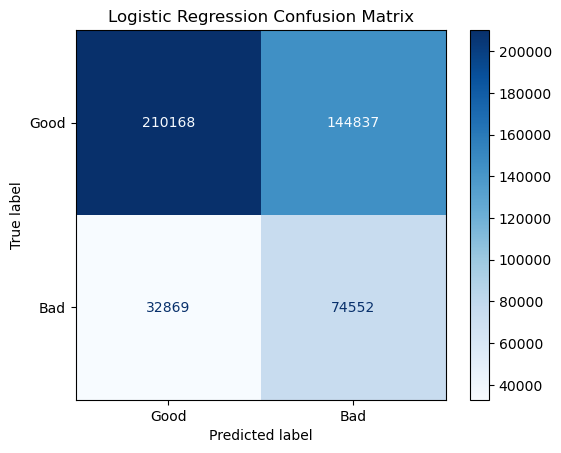

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
logistic_matrix = confusion_matrix(
    y_validation,
    logistic_predictions
)

print(logistic_matrix)

ConfusionMatrixDisplay(
    confusion_matrix=logistic_matrix,
    display_labels=["Good", "Bad"]
).plot(cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")
plt.show()

### The logistic model identifies many bad loans, achieving 69.4% recall, but it also produces a high number of false positives. This trade-off results in lower precision and accuracy. The preferred model and threshold will depend on whether missing a bad loan or incorrectly flagging a good loan is more costly.